In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from fredapi import Fred
#downloaded all the dependencies

In [9]:
gold = yf.Ticker("GLD")
euro = yf.Ticker("^STOXX50E")
fx = yf.Ticker("JPY=X")
ief = yf.Ticker("IEF")
#To understand the diversity of the correlation map - we will use the above three stocks instead and verify if our data is precise
print("Euro Close: ",euro.info["previousClose"])
print("Gold regular market price: ", gold.info["regularMarketPrice"])
print("Japan trading day high:",fx.info["dayHigh"])
print("Treasury IEF: ", ief.info["open"])

Euro Close:  6103.33
Gold regular market price:  411.27
Japan trading day high: 160.024
Treasury IEF:  94.21


[*********************100%***********************]  4 of 4 completed


Ticker           GLD       IEF     JPY=X  ^STOXX50E
Date                                               
2024-02-09       NaN       NaN       NaN        NaN
2024-02-12 -0.002612  0.000952 -0.000616   0.006463
2024-02-13 -0.013789 -0.010996  0.001595  -0.012024
2024-02-14 -0.000596  0.003741  0.008828   0.004252
2024-02-15  0.006724  0.002769 -0.001194   0.007209
...              ...       ...       ...        ...
2026-02-02 -0.040049 -0.001966  0.013319   0.010037
2026-02-03  0.063587  0.000943  0.001553  -0.002024
2026-02-04 -0.000704 -0.000209  0.002290  -0.004150
2026-02-05 -0.026632  0.005863  0.007176  -0.007499
2026-02-06  0.030732  0.000000 -0.000848   0.012269

[517 rows x 4 columns]
Ticker           GLD       IEF     JPY=X  ^STOXX50E
Date                                               
2024-02-09       NaN       NaN       NaN        NaN
2024-02-12 -0.002615  0.000952 -0.000617   0.006442
2024-02-13 -0.013885 -0.011057  0.001594  -0.012097
2024-02-14 -0.000596  0.003734  0.008790

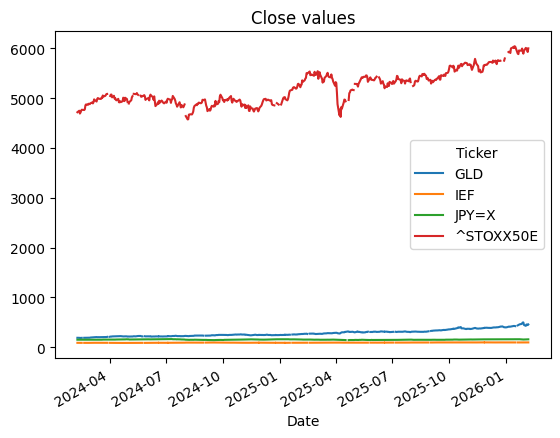

In [14]:
data = yf.download(tickers=["GLD", "^STOXX50E", "JPY=X", "IEF"], start="2024-02-09", end="2026-02-09")
#Again, we compare the values of 2 years while plotting the graph to visualize it
data['Close'].plot(title="Close values")
#pct_change is a function that calculates the daily percentage returns for each asset
# it works with this formula - return(day(t)) = (price(day(t)) - price(day(t-1)))/price(day(t-1))
#The first value is always NaN because it has no value to be compared to
print(data['Close'].pct_change())
simplified_returns = data['Close'].pct_change()
#We can also use the numpy library function of np.log.diff for this
#Log returns are highly favored in algorithmic trading, risk management, and statistical modeling because they are time-additive.
print(np.log(data['Close']).diff())
log_returns = np.log(data['Close']).diff()

In [27]:
#Since we have combined a few different stock exchanges which work in different timezones, 
# the chances of finding missing or NaN values is high
#Hence we will have to apply a few data cleaning mechanisms to increase the quality of our data.
#Moreover, the vast difference in the charts is because a European index in thousands of points vs. a $95 bond ETF vs. a ~150 FX quote
#Lets move onto fixing these
print(data.isnull().sum())
print(data.isna().sum())
#As we can see, the data has a few missing values in it - now the question arises on whether we drop the data or fill it,
#and if we do fill it, what values must we fill it with

#As we know that the null or missing values occur on holidays - 
# when the market is closed, we can fill the missing values with the previously registered value using forward fill
# we can also use the bfill to ensure no starting values are missing
# be careful while using the inplace operation as it a permanent change
data = data.ffill(inplace=True).bfill(inplace=True)

Price   Ticker   
Close   GLD          0
        IEF          0
        JPY=X        0
        ^STOXX50E    0
High    GLD          0
        IEF          0
        JPY=X        0
        ^STOXX50E    0
Low     GLD          0
        IEF          0
        JPY=X        0
        ^STOXX50E    0
Open    GLD          0
        IEF          0
        JPY=X        0
        ^STOXX50E    0
Volume  GLD          0
        IEF          0
        JPY=X        0
        ^STOXX50E    0
dtype: int64
Price   Ticker   
Close   GLD          0
        IEF          0
        JPY=X        0
        ^STOXX50E    0
High    GLD          0
        IEF          0
        JPY=X        0
        ^STOXX50E    0
Low     GLD          0
        IEF          0
        JPY=X        0
        ^STOXX50E    0
Open    GLD          0
        IEF          0
        JPY=X        0
        ^STOXX50E    0
Volume  GLD          0
        IEF          0
        JPY=X        0
        ^STOXX50E    0
dtype: int64


Ticker           GLD       IEF     JPY=X  ^STOXX50E
Date                                               
2024-02-09  1.000000  1.000000  1.000000   1.000000
2024-02-12  0.997388  1.000952  0.999384   1.006463
2024-02-13  0.983635  0.989946  1.000978   0.994362
2024-02-14  0.983049  0.993650  1.009815   0.998590
2024-02-15  0.989659  0.996402  1.008609   1.005789
...              ...       ...       ...        ...
2026-02-02  2.276812  1.087732  1.039817   1.273892
2026-02-03  2.421588  1.088758  1.041431   1.271314
2026-02-04  2.419883  1.088530  1.043816   1.266038
2026-02-05  2.355437  1.094912  1.051307   1.256544
2026-02-06  2.427825  1.094912  1.050416   1.271960

[517 rows x 4 columns]


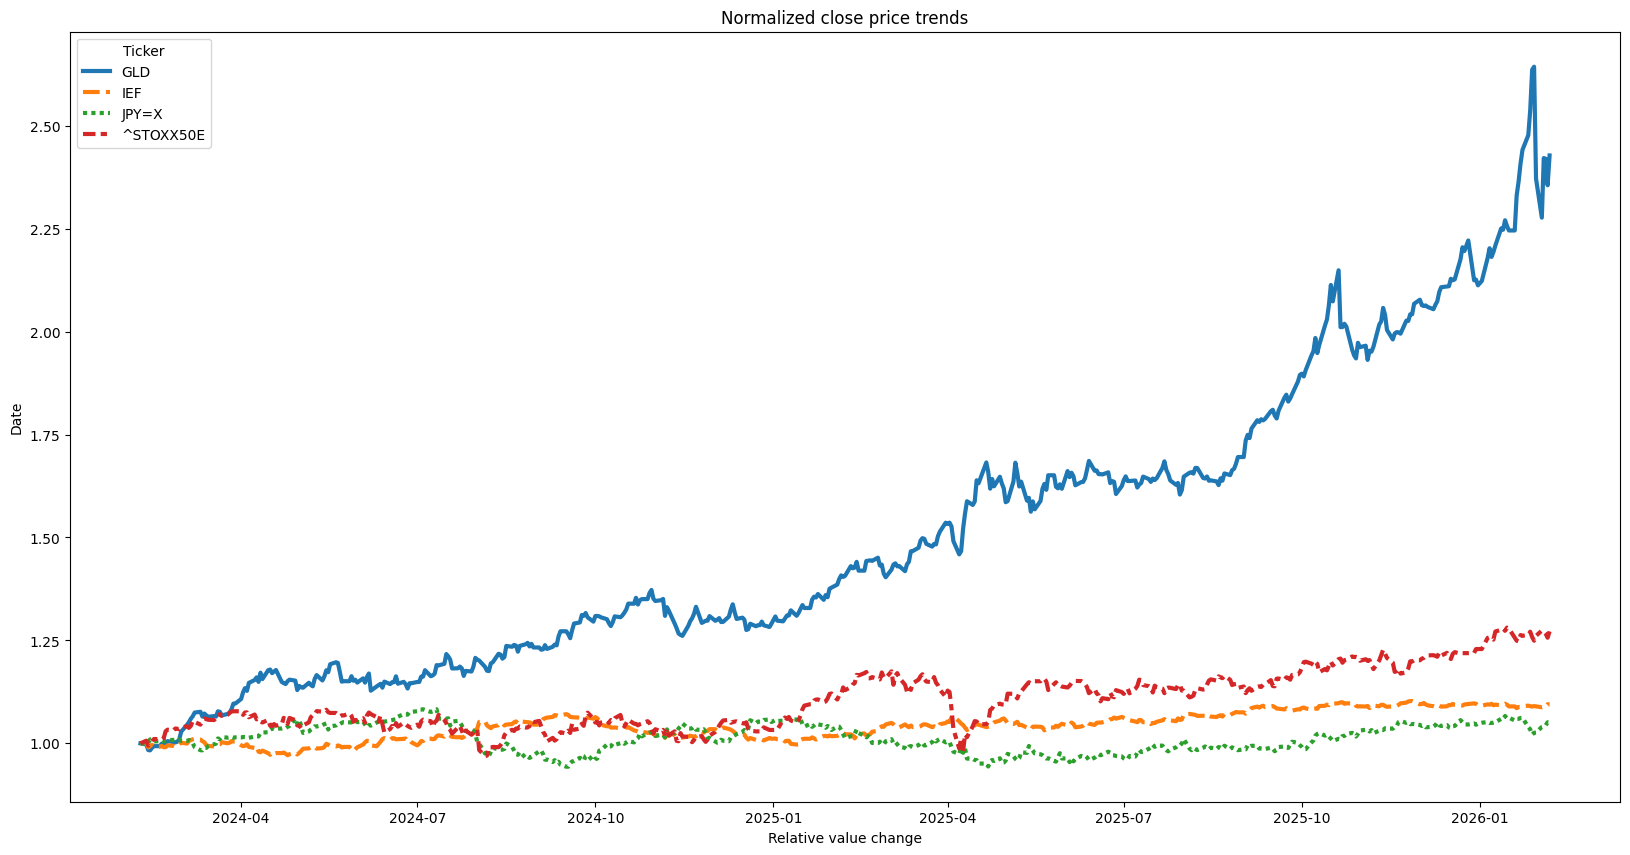

In [ ]:
# now we address the problem of normalizing the data - standardizing the values against which prices are held
# We can use the formula - new_prices = current_price/current_price.iloc[0]
# This brings all the data to start at 1.0
close_cleaned = data['Close']
normalized_data = close_cleaned/close_cleaned.iloc[0]
print(normalized_data)
#Lets see the new graph
plt.figure(figsize=(20,10))
sns.lineplot(data=normalized_data, linewidth=3)
plt.title("Normalized close price trends")
plt.xlabel("Relative value change")
plt.ylabel("Date")
plt.show()
#the graph is much cleaner now